In [507]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
from sklearn.metrics import mean_squared_error ,r2_score
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.linear_model import Ridge
import statsmodels.api as sm
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.linear_model import RidgeCV

In [417]:
df=pd.read_csv("forestfires.csv")
df= df.iloc[:,1:len(df)]
df.head()

,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [419]:
X=df.drop('area', axis=1)
y=df[["area"]]

In [421]:
X.head()

,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0


In [423]:
y.head()

,area
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [425]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the CSV file
df = pd.read_csv("./forestfires.csv")  # Ensure the file path is correct
df = df.dropna()

# Create dummy variables for 'month' and 'day'
dms = pd.get_dummies(df[['month', 'day']])

# Define target variable
y = df["area"]

# Drop 'area', 'month', and 'day' from X
X_ = df.drop(['area', 'month', 'day'], axis=1).astype('float')

# Concatenate dummy variables with X
X = pd.concat([X_, dms], axis=1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=99)


In [427]:
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [429]:
df.shape

(517, 13)

In [431]:
ridge_model= Ridge(alpha = 0.1).fit(X_train,y_train)

In [433]:
ridge_model

Ridge(alpha=0.1)

In [435]:
ridge_model.coef_ #katsayılar

array([  1.37784153,   1.55008201,  -0.1781564 ,   0.20741015,
        -0.12843385,  -0.61804395,   2.1160249 ,  -0.06554508,
         2.35522527, -10.28807394, -26.22084963,  15.69731114,
        32.2653157 , -13.9017013 ,  -7.80707749,  -8.93401189,
       -21.39513032, -27.91927352, -12.81412156, -22.39538169,
        45.65873393,  47.76618661,  -6.69409081,  -6.88113031,
        13.08944514,  -5.374395  ,   5.2365033 ,   1.88045397,
        -1.25678629])

In [436]:
ridge_model.intercept_

4.226403803878513

In [439]:
np.linspace(10,-2,100)

array([10.        ,  9.87878788,  9.75757576,  9.63636364,  9.51515152,
        9.39393939,  9.27272727,  9.15151515,  9.03030303,  8.90909091,
        8.78787879,  8.66666667,  8.54545455,  8.42424242,  8.3030303 ,
        8.18181818,  8.06060606,  7.93939394,  7.81818182,  7.6969697 ,
        7.57575758,  7.45454545,  7.33333333,  7.21212121,  7.09090909,
        6.96969697,  6.84848485,  6.72727273,  6.60606061,  6.48484848,
        6.36363636,  6.24242424,  6.12121212,  6.        ,  5.87878788,
        5.75757576,  5.63636364,  5.51515152,  5.39393939,  5.27272727,
        5.15151515,  5.03030303,  4.90909091,  4.78787879,  4.66666667,
        4.54545455,  4.42424242,  4.3030303 ,  4.18181818,  4.06060606,
        3.93939394,  3.81818182,  3.6969697 ,  3.57575758,  3.45454545,
        3.33333333,  3.21212121,  3.09090909,  2.96969697,  2.84848485,
        2.72727273,  2.60606061,  2.48484848,  2.36363636,  2.24242424,
        2.12121212,  2.        ,  1.87878788,  1.75757576,  1.63

In [441]:
lambdalar = 10**np.linspace(10,-2,100)*0.5

In [443]:
lambdalar


array([5.00000000e+09, 3.78231664e+09, 2.86118383e+09, 2.16438064e+09,
       1.63727458e+09, 1.23853818e+09, 9.36908711e+08, 7.08737081e+08,
       5.36133611e+08, 4.05565415e+08, 3.06795364e+08, 2.32079442e+08,
       1.75559587e+08, 1.32804389e+08, 1.00461650e+08, 7.59955541e+07,
       5.74878498e+07, 4.34874501e+07, 3.28966612e+07, 2.48851178e+07,
       1.88246790e+07, 1.42401793e+07, 1.07721735e+07, 8.14875417e+06,
       6.16423370e+06, 4.66301673e+06, 3.52740116e+06, 2.66834962e+06,
       2.01850863e+06, 1.52692775e+06, 1.15506485e+06, 8.73764200e+05,
       6.60970574e+05, 5.00000000e+05, 3.78231664e+05, 2.86118383e+05,
       2.16438064e+05, 1.63727458e+05, 1.23853818e+05, 9.36908711e+04,
       7.08737081e+04, 5.36133611e+04, 4.05565415e+04, 3.06795364e+04,
       2.32079442e+04, 1.75559587e+04, 1.32804389e+04, 1.00461650e+04,
       7.59955541e+03, 5.74878498e+03, 4.34874501e+03, 3.28966612e+03,
       2.48851178e+03, 1.88246790e+03, 1.42401793e+03, 1.07721735e+03,
      

In [445]:
ridge_model= Ridge()
katsayilar = []

for i in lambdalar:
    ridge_model.set_params(alpha = i)
    ridge_model.fit(X_train, y_train)
    katsayilar.append(ridge_model.coef_)

In [446]:
katsayilar #her bir lambda değerine göre farklıkatsayı oluştu

[array([ 6.44407006e-07,  4.02855914e-07,  1.31202154e-06,  2.69640203e-05,
         7.91557201e-05,  2.02518104e-07,  3.41781086e-06, -8.13821920e-06,
         5.28600884e-08, -1.13111626e-08, -1.68624515e-08, -1.32854929e-08,
         2.86989740e-09, -2.26939338e-08, -5.16103821e-09, -2.27823727e-08,
        -3.00721447e-08, -6.30054492e-08,  2.53448745e-09, -2.58088797e-09,
        -1.34235389e-08,  1.84462925e-07, -9.60451984e-08, -7.76211141e-08,
         1.67038004e-07, -5.35210213e-08,  6.30862758e-08,  7.29054744e-09,
        -1.02274935e-08]),
 array([ 8.51940696e-07,  5.32638369e-07,  1.73287828e-06,  3.56117127e-05,
         1.04463374e-04,  2.66854894e-07,  4.51603419e-06, -1.07574736e-05,
         7.00573524e-08, -1.49578707e-08, -2.22630460e-08, -1.76605807e-08,
         3.80419538e-09, -2.99371559e-08, -6.81594864e-09, -3.01026655e-08,
        -3.97321790e-08, -8.31632337e-08,  3.35688231e-09, -3.40861812e-09,
        -1.77533420e-08,  2.43675692e-07, -1.26970438e-07, -1

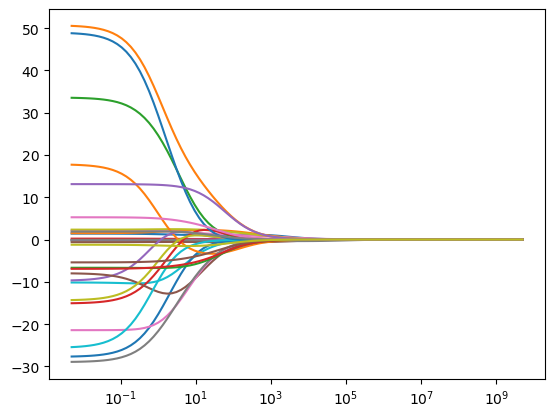

In [448]:
ax=plt.gca()
ax.plot(lambdalar,katsayilar)
ax.set_xscale("log") #katsayıların oluşunu gözlemek

In [450]:
ridge_model= Ridge().fit(X_train, y_train)

In [452]:
y_pred=ridge_model.predict(X_train) #y bağımlı değişken tahminleri


In [454]:

y_pred[0:10] #tahin edilen

array([ 22.94778382,  31.51336618,  28.19683981,  23.12161628,
       -20.08796762,  26.38931976,   7.89600556,  23.92738015,
        -9.45743098, -33.97299461])

In [456]:
y_train[0:10] #gerçek değerler

259     1.38
398     0.00
208    19.23
405     0.00
81      0.00
8       0.00
141     0.55
281    24.77
177     4.69
282     0.00
Name: area, dtype: float64

In [458]:
#Train hatası


RMSE  


38.76180255730273

In [460]:
#Test hatası
y_pred = ridge_model.predict(X_test)

In [462]:
RMSE=np.sqrt(mean_squared_error(y_test, y_pred))
RMSE

38.76180255730273

In [464]:
ridge_model=Ridge().fit(X_train, y_train)
y_pred= ridge_model.predict(X_test) #bağımlı değiken değerlerini tahminet etmek
np.sqrt(mean_squared_error (y_test,y_pred)) #hata hesaplama

38.76180255730273

In [466]:
np.random.randint(0,1000,100) # 0 ile 1000 arasında 100 tane sayı oluştur

array([660, 445, 144, 686,  37,  39, 114, 535, 104, 203, 297, 767, 126,
       752, 815, 770, 244, 837, 941,  65, 231,  21, 483, 304, 199, 946,
       965, 631, 682, 656, 798, 481, 568, 917, 491, 274, 207, 613, 761,
       620, 984, 446, 672, 621, 719, 198, 316, 797, 230, 292, 616, 810,
       754, 109, 865, 908, 684, 833, 575, 219, 430, 134, 596, 631, 347,
       890,  21, 655, 247, 911, 534, 613, 255, 183, 190,  78, 628, 842,
       543, 819, 916, 657, 927, 639, 547, 957, 608, 532, 518,  65, 883,
       382,  42, 230, 282, 332, 563, 418, 904, 154])

In [469]:
lambdalar1=np.random.randint(0,1000,100)

In [470]:
lambdalar2=10**np.linspace(10,-2,100)*0.5

In [473]:
ridgecv=RidgeCV(alphas = lambdalar1 ,scoring= "neg_mean_squared_error", cv=10 )
ridgecv.fit(X_train, y_train)

RidgeCV(alphas=array([853, 301, 728, 774, 274, 104, 602, 637,   8,  99, 860, 968, 161,
       115, 995, 952, 551, 404,  92, 314, 700, 752, 594, 408, 631, 901,
       741, 446, 555, 914, 944, 525, 576, 899, 433, 453, 658, 547, 149,
       139, 107, 960, 576, 569, 542, 633, 647, 982, 970, 179, 699, 856,
       279, 530, 469, 598,  83, 449, 234, 326, 521, 991, 299, 369, 701,
        69, 462, 498, 618, 817, 187, 550,   6, 506, 873, 213, 872, 155,
       945, 512, 392, 861, 277, 409, 437, 352, 795, 511, 399, 325,  98,
       541, 981, 114, 444, 232, 977, 707, 551, 505]),
        cv=10, scoring='neg_mean_squared_error')

In [474]:
ridgecv.alpha_ #optimum parametre değeri

995

In [475]:
#final modeli


In [476]:
ridge_tuned = Ridge(alpha=ridgecv.alpha_).fit(X_train,y_train)

In [477]:
#Test hatası
y_pred=ridge_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

37.136058383900775